# 3. Bit error rate and the reference receiver

EVM tells you how far the received symbols sit from the ideal ones. What a link cares about is how many **bits** come out wrong.
siggen now ships an *ideal* hard-decision receiver (perfect timing, known gain, matched filter, no carrier recovery) and the
textbook curves to compare it with. This notebook measures BER against **Eb/N0**, checks it against theory, and shows where an
ideal receiver stops being enough.

In [1]:
import pathlib, sys
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # the python/ folder, when run from python/notebooks

import matplotlib.pyplot as plt
import numpy as np

import siggen

plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
print("siggen library", siggen.version())

siggen library 0.5.0


## Count errors on one signal

`Signal.bit_errors()` demodulates the matched-filter observations and compares the decided bits with the transmitted ones.
The edge symbols (one RRC span at each end) are excluded, as for EVM.

In [2]:
for snr in (None, 6, 0):
    rx = siggen.generate(modulation="QPSK", symbols=4096, sps=8, snr_db=snr)
    e = rx.bit_errors()
    print(f"snr_db={snr!s:>4}: {e.bit_errors:5d} errors in {e.bit_count} bits -> BER {e.ber:.2e}, SER {e.ser:.2e}")

snr_db=None:     0 errors in 8152 bits -> BER 0.00e+00, SER 0.00e+00
snr_db=   6:     0 errors in 8152 bits -> BER 0.00e+00, SER 0.00e+00
snr_db=   0:    22 errors in 8152 bits -> BER 2.70e-03, SER 5.40e-03


## BER against Eb/N0

The relation between the per-sample SNR the generator uses and Eb/N0 is
`SNR_dB = Eb/N0_dB + 10 log10(bits_per_symbol / samples_per_symbol)`. `ber_curve` applies it for you and stops each point after
`min_errors` errors or `max_bits` bits, whichever comes first.

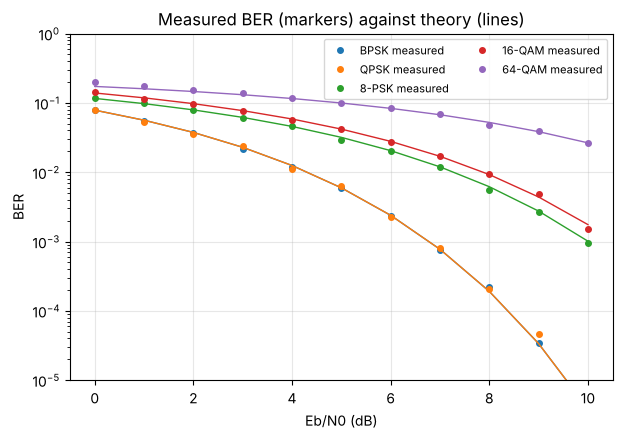

In [3]:
ebn0 = np.arange(0, 11, 1.0)
fig, ax = plt.subplots(figsize=(7, 4.5))
for name in ("BPSK", "QPSK", "8-PSK", "16-QAM", "64-QAM"):
    curve = siggen.ber_curve(ebn0, modulation=name, min_errors=200, max_bits=400_000)
    line, = ax.semilogy(curve.eb_n0_db, np.maximum(curve.ber, 1e-7), "o", label=f"{name} measured", ms=4)
    ax.semilogy(ebn0, siggen.theoretical_ber(name, ebn0), "-", color=line.get_color(), lw=1)
ax.set_xlabel("Eb/N0 (dB)"); ax.set_ylabel("BER"); ax.set_ylim(1e-5, 1); ax.legend(ncol=2, fontsize=8)
ax.set_title("Measured BER (markers) against theory (lines)")
plt.show()

BPSK and QPSK share one curve (QPSK is two BPSK streams); every extra bit per symbol costs Eb/N0. 8-PSK and the QAMs use the
Gray nearest-neighbour approximation, which is tight above a few dB; the markers sit on it from there. Points that saw no
error within the bit budget are clipped to the bottom of the plot.

## The price of differential detection

DBPSK and DQPSK decide on the phase *step* between consecutive symbols, so they need no carrier phase reference, at the cost of
noise appearing in both observations. The penalty is about 1 dB for DQPSK and grows at low Eb/N0 for DBPSK.

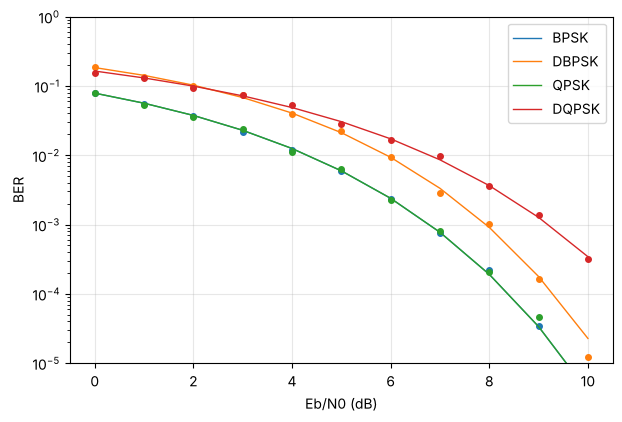

In [4]:
ebn0 = np.arange(0, 11, 1.0)
fig, ax = plt.subplots(figsize=(7, 4.5))
for name, color in (("BPSK", "C0"), ("DBPSK", "C1"), ("QPSK", "C2"), ("DQPSK", "C3")):
    curve = siggen.ber_curve(ebn0, modulation=name, min_errors=200, max_bits=400_000)
    ax.semilogy(curve.eb_n0_db, np.maximum(curve.ber, 1e-7), "o", color=color, ms=4)
    ax.semilogy(ebn0, siggen.theoretical_ber(name, ebn0), "-", color=color, lw=1, label=name)
ax.set_xlabel("Eb/N0 (dB)"); ax.set_ylabel("BER"); ax.set_ylim(1e-5, 1); ax.legend()
plt.show()

## Where an ideal receiver is not enough: carrier offset

The reference receiver has **no carrier recovery**. A coherent scheme therefore fails as soon as the carrier drifts; the
differential ones keep working until the phase rotation *per symbol* eats their decision margin: 90 degrees for DBPSK
(250 Hz at 1000 baud) and 45 degrees for DQPSK (125 Hz).
Here the Eb/N0 is a generous 20 dB, so every error comes from the offset.

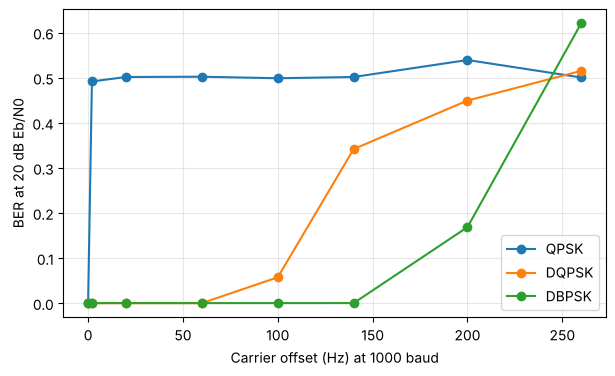

In [5]:
offsets = np.array([0, 2, 20, 60, 100, 140, 200, 260])
fig, ax = plt.subplots(figsize=(7, 4))
for name in ("QPSK", "DQPSK", "DBPSK"):
    bers = [siggen.ber_curve([20], modulation=name, cfo_hz=float(f), max_bits=40_000).ber[0] for f in offsets]
    ax.plot(offsets, bers, "o-", label=name)
ax.set_xlabel("Carrier offset (Hz) at 1000 baud"); ax.set_ylabel("BER at 20 dB Eb/N0"); ax.legend()
plt.show()

QPSK is lost within a couple of hertz (the constellation spins, so the decisions rotate through every quadrant), while DQPSK
holds until noise and its 45 degree margin run out at roughly 100 to 125 Hz, and DBPSK lasts to nearly 200 Hz. A real receiver adds a carrier recovery loop to close that gap; that is a natural next step to build and
validate against this generator.

## Limits to keep in mind

* FSK and MSK have no reference receiver yet (they need a non-coherent or frequency discriminator), so `bit_errors()` returns `None`.
* 8-DPSK and the 32-QAM cross have no closed-form curve here; the measurement still works and `theoretical_ber` returns NaN.
* Everything is hard-decision and uncoded: no FEC, no soft metrics.